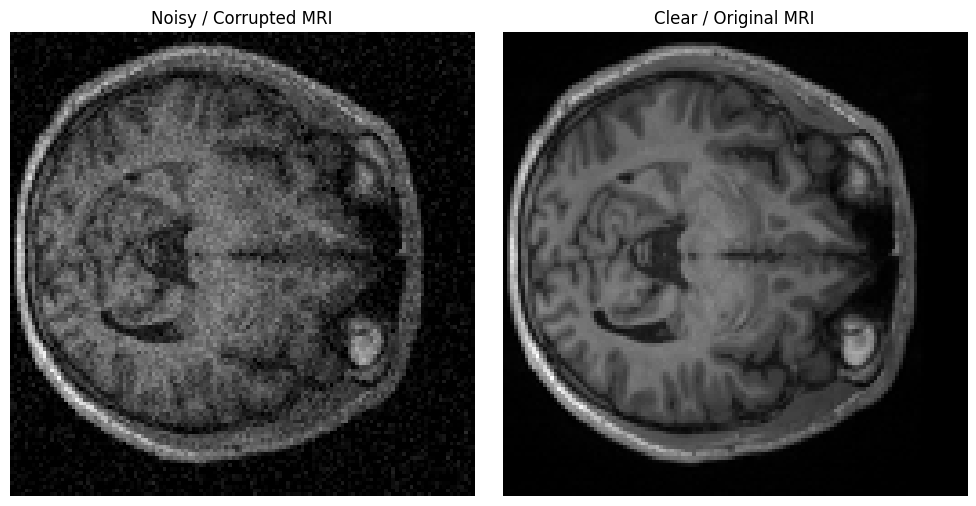

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# =========================
# 1. Local image path
# =========================

image_path = r"C:\Users\rubyp\Downloads\slice_1414.png"


# =========================
# 2. Load MRI image
# =========================

image = Image.open(image_path).convert("L")
image = image.resize((128, 128))

image = np.array(image).astype(np.float32) / 255.0

# Convert to [-1, 1]
image_tensor = torch.tensor(image)
image_tensor = image_tensor * 2.0 - 1.0


# =========================
# 3. Add MRI corruption
# =========================

def add_motion_artifact(image):
    """
    Add k-space motion/noise corruption to an MRI image.
    """

    # FFT → k-space
    kspace = torch.fft.fft2(image)

    corrupted_kspace = kspace.clone()

    h, w = image.shape

    # Corrupt 30% of k-space lines
    num_lines = int(0.30 * h)

    lines = torch.randperm(h)[:num_lines]

    # Add noise to selected k-space lines
    noise_real = torch.randn(num_lines, w)
    noise_imag = torch.randn(num_lines, w)

    noise = torch.complex(noise_real, noise_imag) * 0.8

    corrupted_kspace[lines] += noise

    # Inverse FFT
    corrupted = torch.fft.ifft2(corrupted_kspace).real

    # Additional Gaussian noise
    corrupted += torch.randn_like(corrupted) * 0.08

    # Keep valid range
    corrupted = torch.clamp(corrupted, -1, 1)

    return corrupted


noisy_image = add_motion_artifact(image_tensor)


# =========================
# 4. Convert back to [0, 1]
# =========================

clear_display = (image_tensor + 1) / 2
noisy_display = (noisy_image + 1) / 2


# =========================
# 5. Display
# =========================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(noisy_display.numpy(), cmap="gray")
plt.title("Noisy / Corrupted MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clear_display.numpy(), cmap="gray")
plt.title("Clear / Original MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

Image shape: (240, 240, 4)
Mask shape: (240, 240, 3)


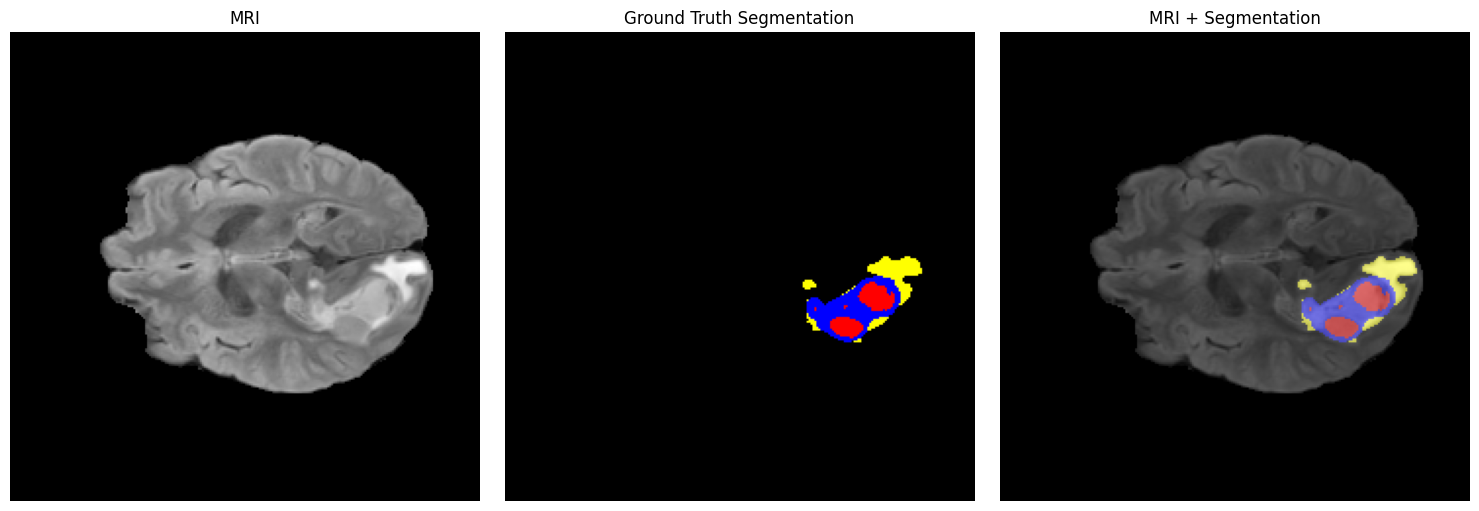

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. H5 FILE
# ============================================================

h5_path = r"C:\Users\rubyp\Downloads\volume_336_slice_69.h5"


# ============================================================
# 2. LOAD H5
# ============================================================

with h5py.File(h5_path, "r") as f:

    image = f["image"][:]
    mask = f["mask"][:]


print("Image shape:", image.shape)
print("Mask shape:", mask.shape)


# ============================================================
# 3. GET MRI IMAGE
# ============================================================

# Use channel 0 for MRI visualization
mri = image[:, :, 0]


# Normalize MRI for display
mri_min = mri.min()
mri_max = mri.max()

mri = (mri - mri_min) / (mri_max - mri_min)


# ============================================================
# 4. CREATE SEGMENTATION RGB MASK
# ============================================================

segmentation = np.zeros(
    (mask.shape[0], mask.shape[1], 3),
    dtype=np.float32
)


# Channel 0 = WT → Red
segmentation[mask[:, :, 0] > 0] = [1, 0, 0]


# Channel 1 = TC → Yellow
segmentation[mask[:, :, 1] > 0] = [1, 1, 0]


# Channel 2 = ET → Blue
segmentation[mask[:, :, 2] > 0] = [0, 0, 1]


# ============================================================
# 5. CREATE OVERLAY
# ============================================================

mri_rgb = np.stack(
    [mri, mri, mri],
    axis=-1
)

overlay = (
    0.55 * mri_rgb +
    0.45 * segmentation
)

overlay = np.clip(
    overlay,
    0,
    1
)


# ============================================================
# 6. DISPLAY
# ============================================================

plt.figure(figsize=(15, 5))


# MRI
plt.subplot(1, 3, 1)

plt.imshow(
    mri,
    cmap="gray"
)

plt.title("MRI")
plt.axis("off")


# Segmentation
plt.subplot(1, 3, 2)

plt.imshow(segmentation)

plt.title("Ground Truth Segmentation")
plt.axis("off")


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(overlay)

plt.title("MRI + Segmentation")
plt.axis("off")


plt.tight_layout()
plt.show()